# Cervical Cancer - exploration and preprocessing

UCI/Kaggle dataset, 858 patients, 36 variables, Python only.

Step 1 of the plan: upload,chech for : missing data, types, duplicates, distributions/outliers,



## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

RAW_PATH = Path("../data/raw/risk_factors_cervical_cancer.csv")
CLEAN_DIR = Path("../data/clean")
PLOTS_DIR = Path("../plots")
CLEAN_DIR.mkdir(exist_ok=True, parents=True)
PLOTS_DIR.mkdir(exist_ok=True, parents=True)


## 2. Loading the data

In [2]:
df_raw = pd.read_csv(RAW_PATH)
print("shape:", df_raw.shape)
df_raw.head()


shape: (858, 36)


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0


## 3. Missing data

Missing values are coded `"?"`. Replacing with real `NaN`.


In [3]:
print(df_raw.dtypes.value_counts())
df = df_raw.replace("?", np.nan)


object    26
int64     10
Name: count, dtype: int64


In [4]:
pct_na = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
pct_na


STDs: Time since first diagnosis      91.72
STDs: Time since last diagnosis       91.72
IUD                                   13.64
IUD (years)                           13.64
Hormonal Contraceptives               12.59
Hormonal Contraceptives (years)       12.59
STDs:HPV                              12.24
STDs:AIDS                             12.24
STDs:Hepatitis B                      12.24
STDs:HIV                              12.24
STDs                                  12.24
STDs:cervical condylomatosis          12.24
STDs:vulvo-perineal condylomatosis    12.24
STDs:syphilis                         12.24
STDs:pelvic inflammatory disease      12.24
STDs:vaginal condylomatosis           12.24
STDs:genital herpes                   12.24
STDs:molluscum contagiosum            12.24
STDs:condylomatosis                   12.24
STDs (number)                         12.24
Num of pregnancies                     6.53
Number of sexual partners              3.03
Smokes                          

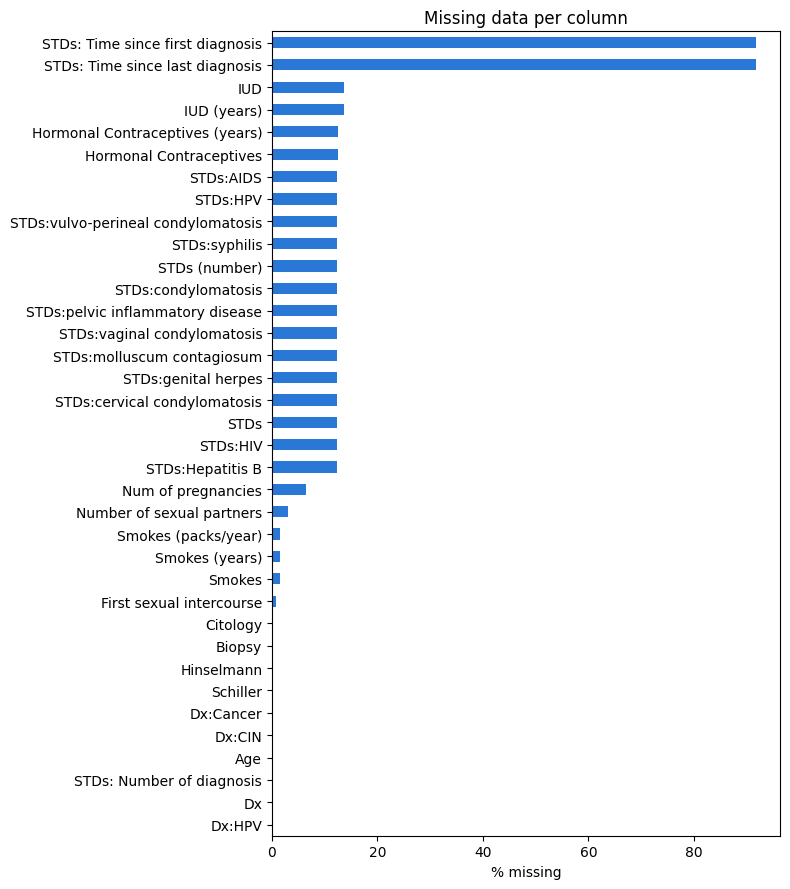

In [5]:
fig, ax = plt.subplots(figsize=(8, 9))
pct_na.sort_values().plot.barh(ax=ax, color="#2a78d6")
ax.set_xlabel("% missing")
ax.set_title("Missing data per column")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "missing_data.png", dpi=130)
plt.show()


`STDs: Time since first/last diagnosis`: 91.7%, only asked if STDs = yes.
`IUD*`/`Hormonal Contraceptives*`/rest of `STDs*`: ~12-14%, same "not applicable" pattern.
Nothing dropped or filled here.


## 4. Data types

Converting `object` columns to numeric (checking `"?"` was the only non-numeric value first).


In [6]:
obj_cols = df.select_dtypes(include="object").columns.tolist()
coerced = df[obj_cols].apply(pd.to_numeric, errors="coerce")
bad = ((coerced.isna()) & (df[obj_cols].notna())).sum()
print("unexpected non-numeric values:", bad[bad > 0].to_dict())

df[obj_cols] = coerced
print(df.dtypes.value_counts())


unexpected non-numeric values: {}
float64    26
int64      10
Name: count, dtype: int64


All clean. Splitting continuous vs. binary/low-count by cardinality (threshold 10 - clean
gap between 5 and 11 distinct values in this data).


In [7]:
n_unique = df.nunique()
CARDINALITY_THRESHOLD = 10
continuous_cols = n_unique[n_unique > CARDINALITY_THRESHOLD].index.tolist()
flag_cols = n_unique[n_unique <= CARDINALITY_THRESHOLD].index.tolist()

print(f"continuous ({len(continuous_cols)}):", continuous_cols)
print(f"\nbinary/low-cardinality ({len(flag_cols)}):", flag_cols)


continuous (10): ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives (years)', 'IUD (years)', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']

binary/low-cardinality (26): ['Smokes', 'Hormonal Contraceptives', 'IUD', 'STDs', 'STDs (number)', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller', 'Citology', 'Biopsy']


## 5. Duplicates

No patient ID, so "duplicate" = identical row, not confirmed same patient.


In [8]:
dup_mask = df.duplicated(keep=False)
print("duplicate rows:", df.duplicated().sum())
print("rows in a duplicate group:", dup_mask.sum())

targets = ["Hinselmann", "Schiller", "Citology", "Biopsy"]
print("positive tests among them:")
print(df.loc[dup_mask, targets].sum())


duplicate rows: 23
rows in a duplicate group: 43
positive tests among them:
Hinselmann    0
Schiller      2
Citology      2
Biopsy        2
dtype: int64


23 exact duplicates, 6 carry a positive test. Left in place here - handled in
`02_cleaning_python.ipynb`.


## 6. Distributions

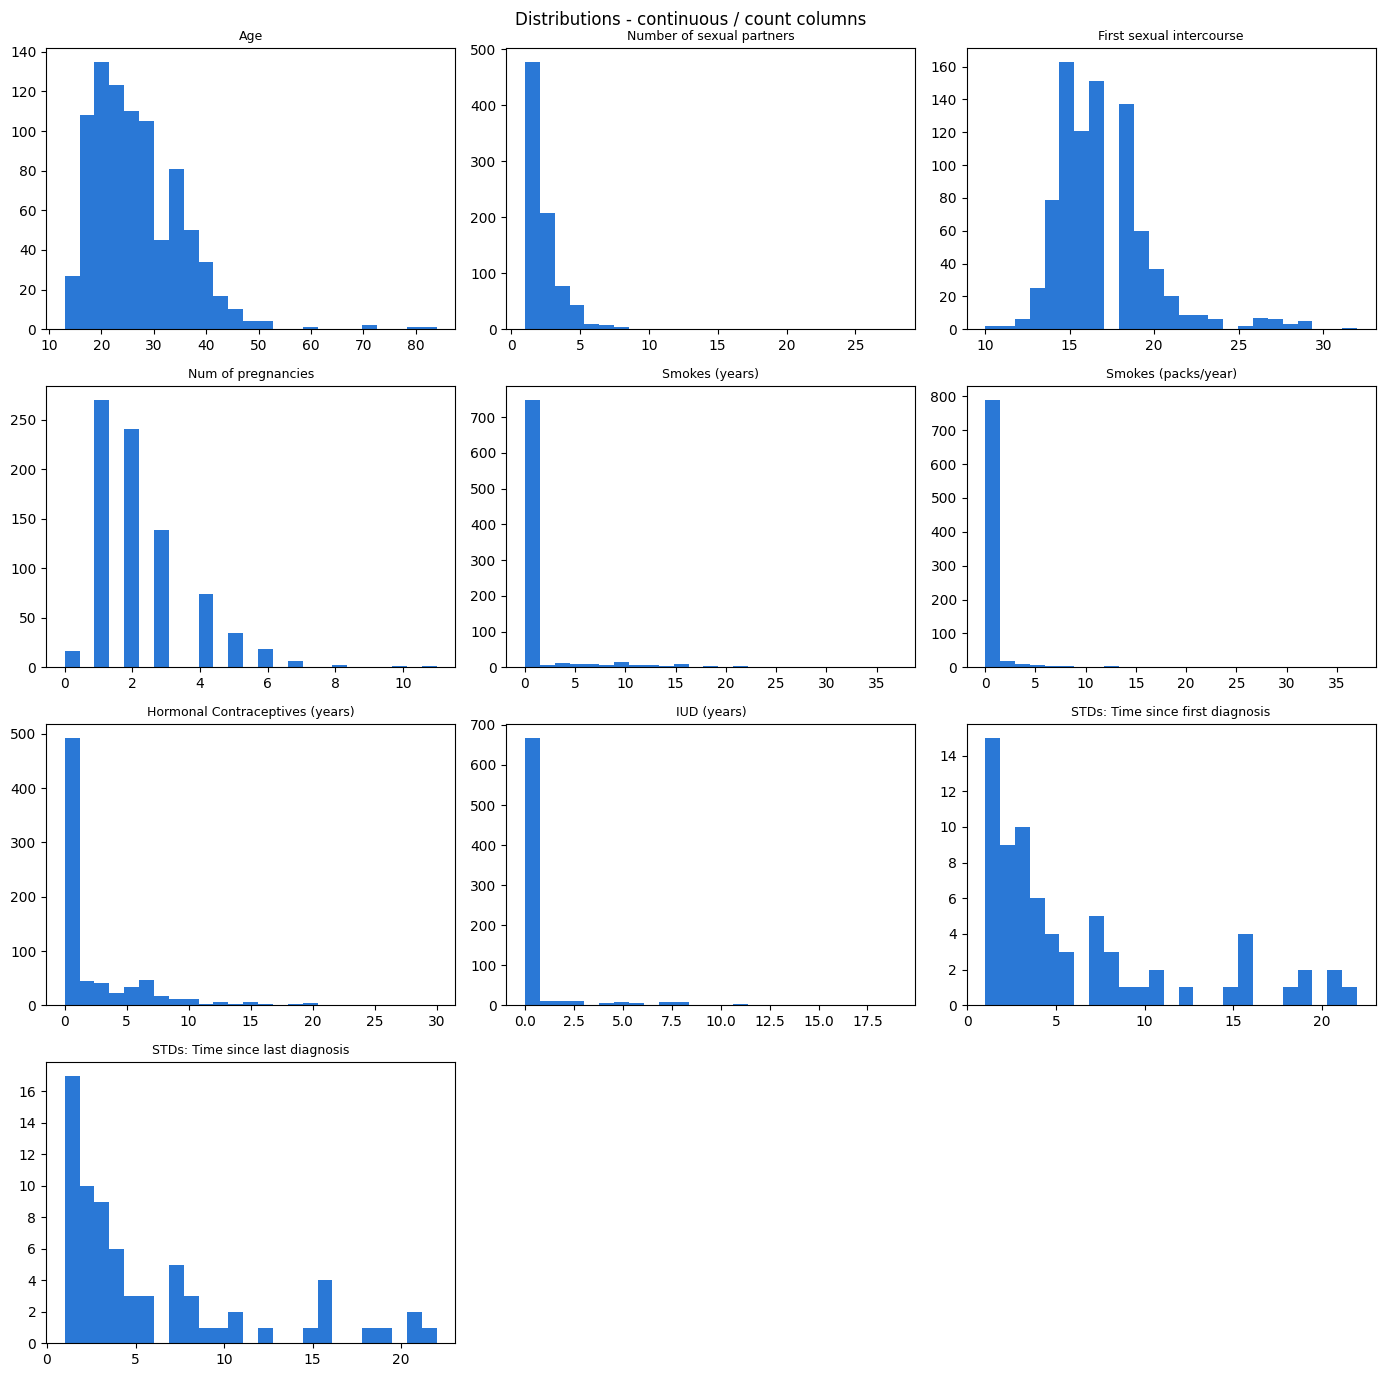

In [9]:
fig, axes = plt.subplots(4, 3, figsize=(14, 14))
for ax, col in zip(axes.flat, continuous_cols):
    ax.hist(df[col].dropna(), bins=25, color="#2a78d6")
    ax.set_title(col, fontsize=9)
for ax in axes.flat[len(continuous_cols):]:
    ax.axis("off")
fig.suptitle("Distributions - continuous / count columns")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "distributions_continuous.png", dpi=130)
plt.show()


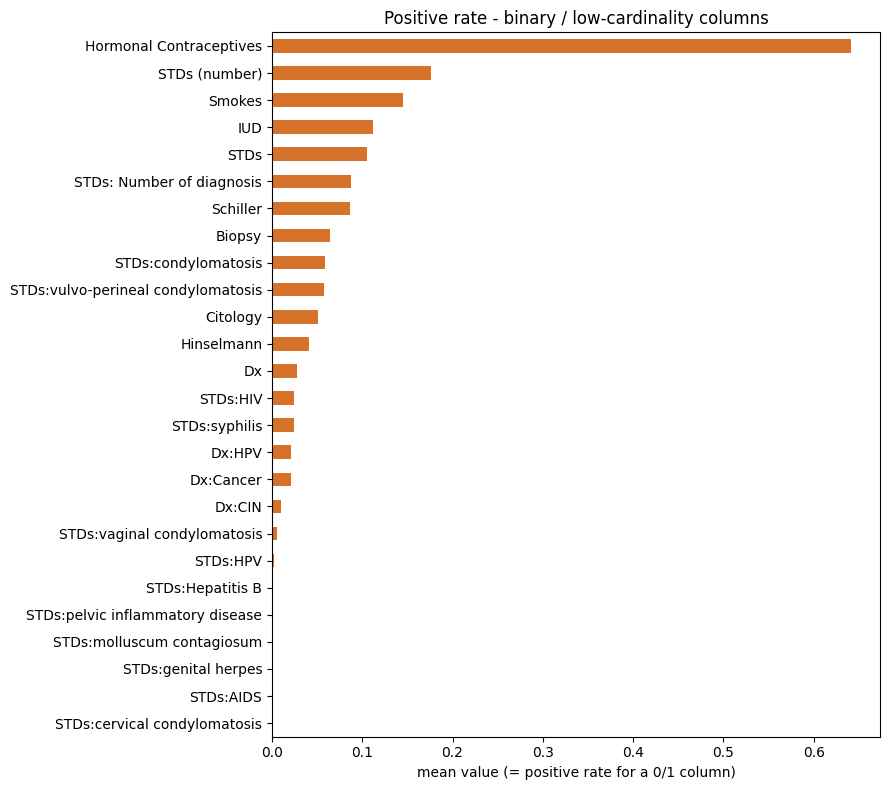

In [10]:
fig, ax = plt.subplots(figsize=(9, 8))
positive_rate = df[flag_cols].mean().sort_values()
positive_rate.plot.barh(ax=ax, color="#d6722a")
ax.set_xlabel("mean value (= positive rate for a 0/1 column)")
ax.set_title("Positive rate - binary / low-cardinality columns")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "positive_rate_flags.png", dpi=130)
plt.show()


Most "continuous" columns are zero-inflated (0 for most patients, a tail for the
minority) - expected, will over-flag as outliers next. `STDs:cervical condylomatosis` and
`STDs:AIDS` are constant at 0, no information, drop in cleaning notebook.


## 7. Outliers (IQR method)

Continuous columns only.


In [11]:
q1 = df[continuous_cols].quantile(0.25)
q3 = df[continuous_cols].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outlier_mask = df[continuous_cols].lt(lower) | df[continuous_cols].gt(upper)

outliers_df = pd.DataFrame({
    "n_outliers": outlier_mask.sum(),
    "n_non_na": df[continuous_cols].notna().sum(),
}).assign(pct_outliers=lambda d: (d.n_outliers / d.n_non_na * 100).round(2))
outliers_df = outliers_df.sort_values("pct_outliers", ascending=False)

outliers_df.to_csv("../outliers.csv")
outliers_df


,n_outliers,n_non_na,pct_outliers
Smokes (years),123,845,14.56
Smokes (packs/year),123,845,14.56
STDs: Time since last diagnosis,9,71,12.68
IUD (years),83,741,11.20
Hormonal Contraceptives (years),68,750,9.07
STDs: Time since first diagnosis,6,71,8.45
Number of sexual partners,68,832,8.17
First sexual intercourse,41,851,4.82
Num of pregnancies,10,802,1.25
Age,8,858,0.93


Smokes/IUD/HC top the list from zero-inflation, not bad data. `Age` and `Num of
pregnancies` look like genuine tails.


## 8. Descriptive statistics

In [12]:
desc = df.describe().T.rename(columns={"50%": "median"})
desc["variance"] = df.var()
desc = desc[["count", "mean", "median", "std", "variance", "min", "max"]]
desc.to_csv("../describe_all.csv")
desc


,count,mean,median,std,variance,min,max
Age,858.0,26.820513,25.0,8.497948,72.215121,13.0,84.0
Number of sexual partners,832.0,2.527644,2.0,1.667760,2.781425,1.0,28.0
First sexual intercourse,851.0,16.995300,17.0,2.803355,7.858801,10.0,32.0
Num of pregnancies,802.0,2.275561,2.0,1.447414,2.095007,0.0,11.0
Smokes,845.0,0.145562,0.0,0.352876,0.124521,0.0,1.0
Smokes (years),845.0,1.219721,0.0,4.089017,16.720060,0.0,37.0
Smokes (packs/year),845.0,0.453144,0.0,2.226610,4.957791,0.0,37.0
Hormonal Contraceptives,750.0,0.641333,1.0,0.479929,0.230332,0.0,1.0
Hormonal Contraceptives (years),750.0,2.256419,0.5,3.764254,14.169605,0.0,30.0
IUD,741.0,0.112011,0.0,0.315593,0.099599,0.0,1.0


## 9. Target columns

`Hinselmann`, `Schiller`, `Citology`, `Biopsy` are actual test results. `Dx*` are
self-reported prior diagnoses (features, not outcomes).


In [13]:
for c in ["Hinselmann", "Schiller", "Citology", "Biopsy", "Dx", "Dx:Cancer", "Dx:CIN", "Dx:HPV"]:
    pos = int((df[c] == 1).sum())
    print(f"{c:12s} {pos:3d} / {len(df)}  ({pos/len(df)*100:.1f}%)")


Hinselmann    35 / 858  (4.1%)
Schiller      74 / 858  (8.6%)
Citology      44 / 858  (5.1%)
Biopsy        55 / 858  (6.4%)
Dx            24 / 858  (2.8%)
Dx:Cancer     18 / 858  (2.1%)
Dx:CIN         9 / 858  (1.0%)
Dx:HPV        18 / 858  (2.1%)


`Biopsy` is the only histological diagnosis (the other 3 are screening tests it
confirms/rules out) - most likely primary target.


## 10. Recap

In [14]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Global % missing: {df.isna().values.mean()*100:.2f}%")
print(f"Continuous: {len(continuous_cols)}, Binary/low-card: {len(flag_cols)}")
print(f"Exact duplicates: {df.duplicated().sum()}")
print()
print("To handle in 02_cleaning_python.ipynb:")
print(" - STDs: Time since first/last diagnosis: 91.7% missing (S3)")
print(" - STDs:cervical condylomatosis, STDs:AIDS: zero variance (S6)")
print(" - 23 exact duplicates, 6 with a positive test (S5)")
print(" - Likely target: Biopsy (S9)")


Rows: 858, Columns: 36
Global % missing: 11.73%
Continuous: 10, Binary/low-card: 26
Exact duplicates: 23

To handle in 02_cleaning_python.ipynb:
 - STDs: Time since first/last diagnosis: 91.7% missing (S3)
 - STDs:cervical condylomatosis, STDs:AIDS: zero variance (S6)
 - 23 exact duplicates, 6 with a positive test (S5)
 - Likely target: Biopsy (S9)


## 11. Export

`cervical_cancer_clean.csv`/`.parquet` - typed version of the raw data, nothing dropped
or imputed.


In [15]:
df.to_csv(CLEAN_DIR / "cervical_cancer_clean.csv", index=False)
df.to_parquet(CLEAN_DIR / "cervical_cancer_clean.parquet", index=False)
print("exported:", df.shape)


exported: (858, 36)
